In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.


['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
import cv2


In [3]:
from PIL import Image
from matplotlib import pyplot as plt


In [4]:
import torch


In [5]:
DATA_DIR = '../input/'
TRAIN_DIR = DATA_DIR+'train/train/'
NAMES_DIR = DATA_DIR+'train.csv'


In [6]:
TEST_DIR= '../input/test/test/'


In [7]:
os.listdir(TEST_DIR)


['76bad42ebc1ed65f7f50c06fd17849db.jpg',
 'f620bd2745d51c25cd05eca4f7c4da94.jpg',
 '0e47e71ea2829d6d88944482ada145a5.jpg',
 'd66598ea219072e9c0b98e1a162cc8f6.jpg',
 '3288a35f07e97293155203bec36c0a8d.jpg',
 '05e406596f183ddc1d771de2c7af6eb1.jpg',
 '454f59bef7140259bbb9875a836355cd.jpg',
 '589de864efdaa264d19112d946d17826.jpg',
 'b5f7b64eb412f94d352ad01e6e6106d7.jpg',
 '890ae48097378d600cfbc0b93566c155.jpg',
 '9d052bee693b53a48fa3503f1eafbea8.jpg',
 '2c7e6f5d7b6165001bbb9523d2efd4ee.jpg',
 '106b2f33541f5b23cb4805cdffc87db6.jpg',
 '712ed765f98a19b8cd21a5a8c96ff4a5.jpg',
 'cebe5aeeb39cdc7349e4783353e6254f.jpg',
 'df1e111ef8ec047a456ba11ba7ef96f0.jpg',
 '73ca87e899048fb0f1a020361af74eac.jpg',
 '4e98c9d667be711ac1b593e79906d2e7.jpg',
 'f852db0e5fcded7e80be3a8b3993a66d.jpg',
 '8886a5647fee68f9ef200fa2bd7b9c22.jpg',
 '74f611a1f3d41313fe35ec75c50e3c15.jpg',
 '2246209a6d93a68be1dbf1fcd66e78ab.jpg',
 'a543d2de2b076d4ddc5406583221ea8d.jpg',
 'cc1a534bf86d2adbb449091229fa2148.jpg',
 '67d8fe28186d32

In [8]:
train_names = pd.read_csv(NAMES_DIR)
train_names.shape


(14175, 2)

In [9]:
len(os.listdir(TRAIN_DIR))


14176

In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import torchvision.transforms as transforms


0


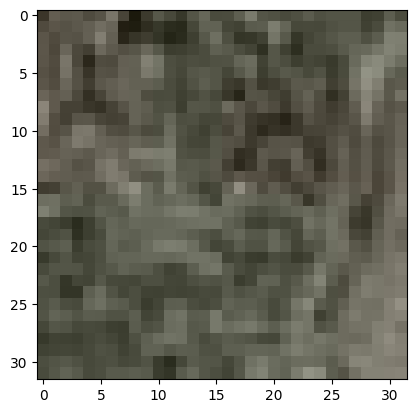

In [11]:
def show_image(index):
    image = Image.open(TRAIN_DIR+str(train_names['id'][index]))
    plt.imshow(image)
    print(train_names['has_cactus'][index])

    
show_image(20)


In [12]:
class HasCactusDataset(Dataset):
    
    def __init__(self, csv_file, root_dir, transform=None):
    
        self.img_names = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name=os.path.join(self.root_dir,
                             self.img_names.iloc[idx, 0])
        image = cv2.imread(img_name)
        image = torch.from_numpy(image)
        
        image = image.permute(2, 0, 1)
        #print(image)
        
        has_cactus = self.img_names.iloc[idx, 1]
        #print(has_cactus)
        sample = [image,has_cactus]
            
        return sample


In [13]:
hasCactusDataset = HasCactusDataset(csv_file=DATA_DIR+'train.csv',
                                   root_dir=TRAIN_DIR,
                                   transform=transforms.Compose([
                                       transforms.ToTensor()
                                   ]))


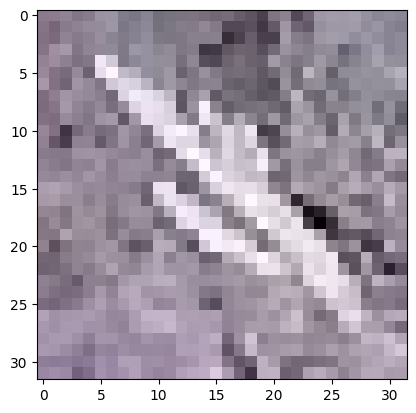

In [14]:
plt.imshow(hasCactusDataset[19][0].permute(1, 2, 0).numpy())


In [15]:
dataloader = DataLoader(hasCactusDataset, 
                       batch_size=128,
                       shuffle=True)


In [16]:
import torch.nn as nn
import torch.nn.functional as F


In [17]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 10, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(10, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv3 = nn.Conv2d(16, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x =self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        #print(x.shape)
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x
    
net = Net()


In [18]:
import torch.optim as optim

critation = nn.BCELoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [19]:
for epoch in range(10):
    running_loss=0
    print("epoch {} started...", format(epoch))
    for i, data in enumerate(iter(dataloader)):
        image, label = data
        optimizer.zero_grad()
        
        inputs = image.type(torch.FloatTensor)
        label = label.view(-1, 1)
        
        outputs = net(inputs)
        loss=critation(outputs.type(torch.FloatTensor),label.type(torch.FloatTensor))
        loss.backward()
        optimizer.step()
        
        
    print("epoch {} complete", format(epoch))
        
print('finished Trainig...')


epoch {} started... 0
epoch {} complete 0
epoch {} started... 1
epoch {} complete 1
epoch {} started... 2
epoch {} complete 2
epoch {} started... 3
epoch {} complete 3
epoch {} started... 4
epoch {} complete 4
epoch {} started... 5
epoch {} complete 5
epoch {} started... 6
epoch {} complete 6
epoch {} started... 7
epoch {} complete 7
epoch {} started... 8
epoch {} complete 8
epoch {} started... 9
epoch {} complete 9
finished Trainig...


In [20]:
data = next(iter(dataloader))


In [21]:
os.listdir(TEST_DIR)


['76bad42ebc1ed65f7f50c06fd17849db.jpg',
 'f620bd2745d51c25cd05eca4f7c4da94.jpg',
 '0e47e71ea2829d6d88944482ada145a5.jpg',
 'd66598ea219072e9c0b98e1a162cc8f6.jpg',
 '3288a35f07e97293155203bec36c0a8d.jpg',
 '05e406596f183ddc1d771de2c7af6eb1.jpg',
 '454f59bef7140259bbb9875a836355cd.jpg',
 '589de864efdaa264d19112d946d17826.jpg',
 'b5f7b64eb412f94d352ad01e6e6106d7.jpg',
 '890ae48097378d600cfbc0b93566c155.jpg',
 '9d052bee693b53a48fa3503f1eafbea8.jpg',
 '2c7e6f5d7b6165001bbb9523d2efd4ee.jpg',
 '106b2f33541f5b23cb4805cdffc87db6.jpg',
 '712ed765f98a19b8cd21a5a8c96ff4a5.jpg',
 'cebe5aeeb39cdc7349e4783353e6254f.jpg',
 'df1e111ef8ec047a456ba11ba7ef96f0.jpg',
 '73ca87e899048fb0f1a020361af74eac.jpg',
 '4e98c9d667be711ac1b593e79906d2e7.jpg',
 'f852db0e5fcded7e80be3a8b3993a66d.jpg',
 '8886a5647fee68f9ef200fa2bd7b9c22.jpg',
 '74f611a1f3d41313fe35ec75c50e3c15.jpg',
 '2246209a6d93a68be1dbf1fcd66e78ab.jpg',
 'a543d2de2b076d4ddc5406583221ea8d.jpg',
 'cc1a534bf86d2adbb449091229fa2148.jpg',
 '67d8fe28186d32

In [22]:
class TestSet(Dataset):
    
    def __init__(self, root_dir, transform=None):
    
        self.img_names = os.listdir(root_dir)
        self.root_dir = root_dir
        self.transform = transform
    
    def __len__(self):
        return len(os.listdir(self.root_dir))

    def __getitem__(self, idx):
        img_loc=os.path.join(self.root_dir,
                             self.img_names[idx])
        img_name = self.img_names[idx]
        #print(img_name)
        image = cv2.imread(img_loc)
        image = torch.from_numpy(image)
        
        image = image.permute(2, 0, 1)
        
        name = img_name
        #print(name)
        sample = [image,name]
            
        return sample


In [23]:
testSet = TestSet(root_dir=TEST_DIR,
                                   transform=transforms.Compose([
                                       transforms.ToTensor()
                                   ]))


In [24]:
testloader = DataLoader(testSet, 
                       batch_size=1,
                       shuffle=True)


In [25]:
tstdata = next(iter(testloader))


In [26]:
tstdata[0].shape


torch.Size([1, 3, 32, 32])

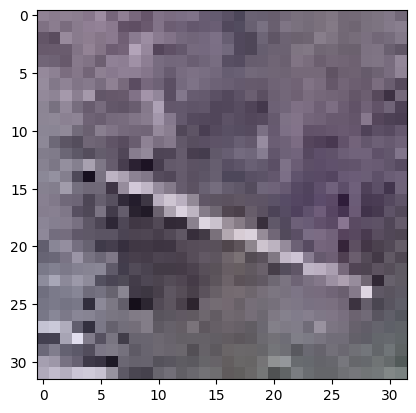

In [27]:
plt.imshow(tstdata[0][0].permute(1,2,0).numpy())


In [28]:
tst_outputs =[]
tst_names = []
for i, data in enumerate(iter(testloader), 0):
    image, name = data[0], data[1]
    print(name[0])
    inputs = image.type(torch.FloatTensor)
    tst_outputs.append(net(inputs).item())
    tst_names.append(name[0])


ba069d7fbdfd6951de6f740fd5172a2d.jpg
1a7347955b561e7cea4db40f24a4c76e.jpg
abfa62089cc0ac9638c5b73a328e5713.jpg
9c9a7c22aa67543af463267baafb6b7a.jpg
e8df3850f542f7b33aa094e16ea70141.jpg
8a1db4703d7fbf1c726c50e767554ffe.jpg
05b38c7dbb76d5adafe60fc0cce0c3ff.jpg
6e6d422e8dc8f56d95c4450e33a81b61.jpg
f7b72b7d34ce6d45ea9dd39f8724b254.jpg
f3c2b89f5269dc2ec15741d687caaf2a.jpg
931db82354497eff7a9cc77f517945d8.jpg
19830ded4959592844bbf2d4d8a4632e.jpg
a07a3c5c9bc380b478c1cce0d0a55861.jpg
44906601c6bcd0a1f39b82fad2004ea1.jpg
98c8b7e5a12c371349170e2473698476.jpg
2c79ddcf8b19886ebd9507c8d8c12738.jpg
9cce1aa92a3da246487584745401bc90.jpg
6c11d59c4973c12c556e5b94f0276222.jpg
1c8c5d4f0c8cca16ff714e66d4d019a7.jpg
5c1a08f059433918a57934c4a1cfd787.jpg
31242e491212fd87776e0e18b6bf4c9c.jpg
dd6570aa2feb2b1bbe279fe5b597fd7a.jpg
1d7dd714854edf235c74af67243f38d4.jpg
c5dbc4bb889c96e38f270c5cc5b1da0a.jpg
1cbeb62e8b1bfeffcdab164bc9f49add.jpg
7c1e2b2f523ee03d84fa8df4c080b92b.jpg
f7092cd665aaacca617dfd5d3e7e74df.jpg
6

TypeError: expected np.ndarray (got NoneType)

In [29]:
len(tst_outputs)


1710

In [30]:
tst_outputs


[0.9947546720504761,
 0.00534800486639142,
 0.9998365640640259,
 0.9999998807907104,
 0.9974281191825867,
 0.9936210513114929,
 0.9992278814315796,
 0.9999988079071045,
 0.10553538054227829,
 0.9979839324951172,
 0.999819815158844,
 0.01502940896898508,
 0.9999768733978271,
 0.020298724994063377,
 0.9999998807907104,
 0.9994888305664062,
 0.9999995231628418,
 0.21248063445091248,
 0.9996321201324463,
 0.9995643496513367,
 0.008823390118777752,
 0.012349173426628113,
 0.05315524712204933,
 0.7022943496704102,
 0.999981164932251,
 0.9999954700469971,
 0.011362218298017979,
 0.028676388785243034,
 0.003834808710962534,
 0.5110558867454529,
 0.9999680519104004,
 0.9999998807907104,
 0.9999934434890747,
 0.997911274433136,
 0.9999982118606567,
 0.2904484272003174,
 0.9999902248382568,
 0.999840497970581,
 0.9999980926513672,
 0.04319474473595619,
 0.0023562158457934856,
 0.995935320854187,
 0.9946631193161011,
 0.0310619305819273,
 0.25472646951675415,
 0.9999191761016846,
 0.99984872341156

In [31]:
len(tst_names)


1710

In [32]:
my_submission = pd.DataFrame({'id': tst_names, 'has_cactus': tst_outputs})
# you could use any filename. We choose submission here
my_submission.to_csv('submission.csv', index=False)


In [33]:
tst_names


['ba069d7fbdfd6951de6f740fd5172a2d.jpg',
 '1a7347955b561e7cea4db40f24a4c76e.jpg',
 'abfa62089cc0ac9638c5b73a328e5713.jpg',
 '9c9a7c22aa67543af463267baafb6b7a.jpg',
 'e8df3850f542f7b33aa094e16ea70141.jpg',
 '8a1db4703d7fbf1c726c50e767554ffe.jpg',
 '05b38c7dbb76d5adafe60fc0cce0c3ff.jpg',
 '6e6d422e8dc8f56d95c4450e33a81b61.jpg',
 'f7b72b7d34ce6d45ea9dd39f8724b254.jpg',
 'f3c2b89f5269dc2ec15741d687caaf2a.jpg',
 '931db82354497eff7a9cc77f517945d8.jpg',
 '19830ded4959592844bbf2d4d8a4632e.jpg',
 'a07a3c5c9bc380b478c1cce0d0a55861.jpg',
 '44906601c6bcd0a1f39b82fad2004ea1.jpg',
 '98c8b7e5a12c371349170e2473698476.jpg',
 '2c79ddcf8b19886ebd9507c8d8c12738.jpg',
 '9cce1aa92a3da246487584745401bc90.jpg',
 '6c11d59c4973c12c556e5b94f0276222.jpg',
 '1c8c5d4f0c8cca16ff714e66d4d019a7.jpg',
 '5c1a08f059433918a57934c4a1cfd787.jpg',
 '31242e491212fd87776e0e18b6bf4c9c.jpg',
 'dd6570aa2feb2b1bbe279fe5b597fd7a.jpg',
 '1d7dd714854edf235c74af67243f38d4.jpg',
 'c5dbc4bb889c96e38f270c5cc5b1da0a.jpg',
 '1cbeb62e8b1bfe